In [1]:
from pathlib import Path
import sys

sys.path.append('..')

from utils import plot_silhouette

In [2]:
import pandas as pd
import seaborn as sns
import seaborn.objects as so
from seaborn import axes_style
import matplotlib.pyplot as plt

In [3]:
from sktime.transformations.series.adapt import TabularToSeriesAdaptor
from sktime.clustering.k_means import TimeSeriesKMeans
from sktime.dists_kernels.dtw import DtwDist
from sktime.alignment.dtw_numba import AlignerDtwNumba
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score


In [4]:
sns.set_theme(context='notebook', style='whitegrid', palette='muted')
theme_dict = {**axes_style('whitegrid'), 'context': 'notebook', 'palette': 'muted'}
so.Plot.config.theme.update(theme_dict)

In [5]:
data_dir = Path('../../results')

In [6]:
train = pd.read_csv(data_dir / 'train_ts.csv', index_col='id')
# Make rating category ordinal
train['rating_category'] = pd.Categorical(train['rating_category'],
               categories=['Low', 'Medium Low', 'Medium', 'Medium High', 'High'],
               ordered=True)
train.sort_values('numVotes', ascending=False).head(5)

,title,startYear,runtimeMinutes,numVotes,countryOfOrigin,awardsOrNominations,awards,nominations,rating,genre,...,90,91,92,93,94,95,96,97,98,99
id,,,,,,,,,,,,,,,,,,,,,
tt0816692,Interstellar,2014,169,2390667,"['US', 'GB', 'CA']",True,44.0,148.0,8.7,"['Adventure', 'Drama', 'Sci-Fi']",...,593663.0,720577.0,896340.0,1070807.0,991763.0,910905.0,786939.0,660732.0,710859.0,763250.0
tt0993846,The Wolf of Wall Street,2013,180,1711865,['US'],True,38.0,180.0,8.2,"['Biography', 'Comedy', 'Crime']",...,516835.0,636727.0,921125.0,1212685.0,959817.0,733352.0,485552.0,215064.0,230368.0,244186.0
tt7286456,Joker,2019,122,1632868,"['US', 'CA', 'AU']",True,120.0,246.0,8.3,"['Crime', 'Drama', 'Thriller']",...,1908740.0,1371816.0,943600.0,426673.0,513630.0,609986.0,533751.0,443301.0,383414.0,328871.0
tt4154796,Avengers: Endgame,2019,181,1380913,['US'],NaN,NaN,NaN,8.4,"['Action', 'Adventure', 'Sci-Fi']",...,1829579.0,1583859.0,1057981.0,598373.0,700030.0,790276.0,686876.0,601476.0,570854.0,547331.0
tt4154756,Avengers: Infinity War,2018,149,1311271,"['US', 'NO']",True,48.0,80.0,8.4,"['Action', 'Adventure', 'Sci-Fi']",...,2644515.0,2403780.0,1719860.0,922933.0,1054992.0,1182541.0,1051254.0,895177.0,820151.0,766901.0


In [7]:
train.shape

(850, 113)

## Preparation of the dataset

Convert in a format that sktime can use. For future reference, for panel timeseries expects on of:
- pandas dataframe with row multi-index (instances, time) cols = variables;
- 3D numpy array
- list of pandas dataframes with list index=instances, rows = time points and cols = variables

[see documentation](https://www.sktime.net/en/latest/examples/AA_datatypes_and_datasets.html#Section-1.2:-Time-series-panels---the-%22Panel%22-scitype)

In [8]:
train_X = train[[str(i) for i in range(100)]]
train_X = train_X.reset_index().melt(id_vars='id', var_name='time')
train_X['time'] = train_X['time'].astype(int)
train_X = train_X.set_index(['id', 'time'])
train_X

,,value
id,time,
tt10855768,0,3433703.0
tt3766354,0,13375850.0
tt6791096,0,6199651.0
tt1821549,0,35536.0
tt7144666,0,10241355.0
...,...,...
tt7668870,99,26209.0
tt8884430,99,36465.0
tt9883996,99,2417.0


Sanity check on the output of the transformers.

In [9]:
scaler = TabularToSeriesAdaptor(StandardScaler())

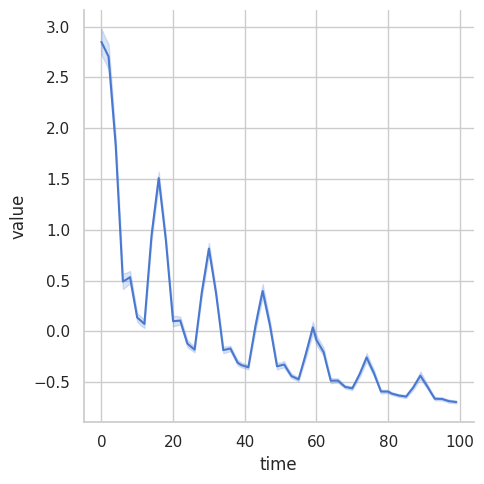

In [10]:
sns.relplot(scaler.fit_transform(train_X), x='time', y='value', kind='line')

## Visualization of some distances

In [11]:
idxs =  ['tt0816692', 'tt4154796', 'tt1663202', 'tt6751668']

movies = [train.loc[idx, 'title'] for idx in idxs]

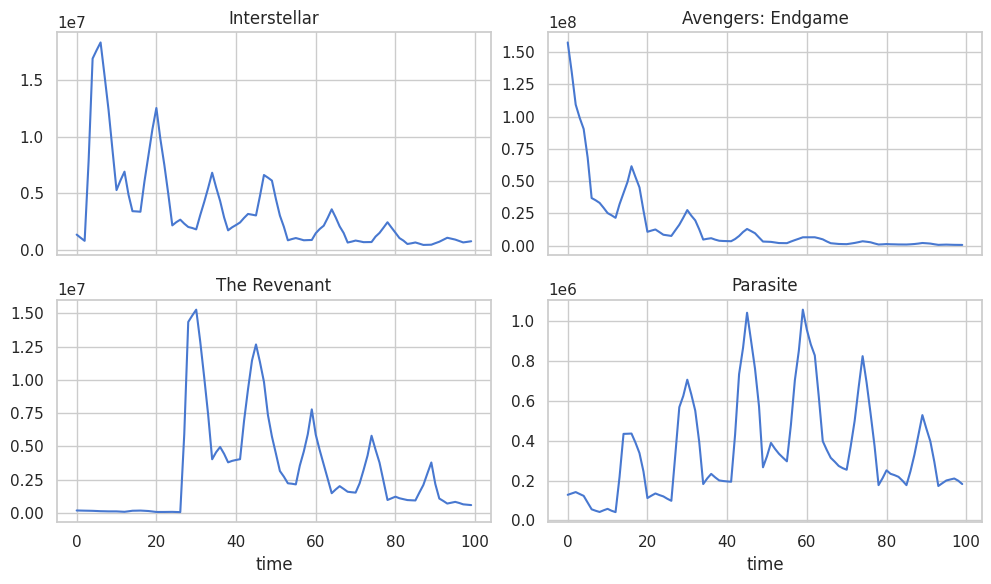

In [12]:
fig, axs = plt.subplots(2, 2, sharey=False, sharex=True, figsize=(10, 6))
sns.lineplot(train_X.loc[idxs[0]], legend=False, ax=axs[0, 0])
axs[0, 0].set_title(movies[0])
sns.lineplot(train_X.loc[idxs[1]], legend=False, ax=axs[0, 1])
axs[0, 1].set_title(movies[1])
sns.lineplot(train_X.loc[idxs[2]], legend=False, ax=axs[1, 0])
axs[1, 0].set_title(movies[2])
sns.lineplot(train_X.loc[idxs[3]], legend=False, ax=axs[1, 1])
axs[1, 1].set_title(movies[3])
plt.tight_layout()

In [13]:
train_X_norm = scaler.fit_transform(train_X)

In [14]:
data = train_X_norm.loc[idxs]

Text(0.5, 1.0, 'Distance matrix (STW with band=0.1)')

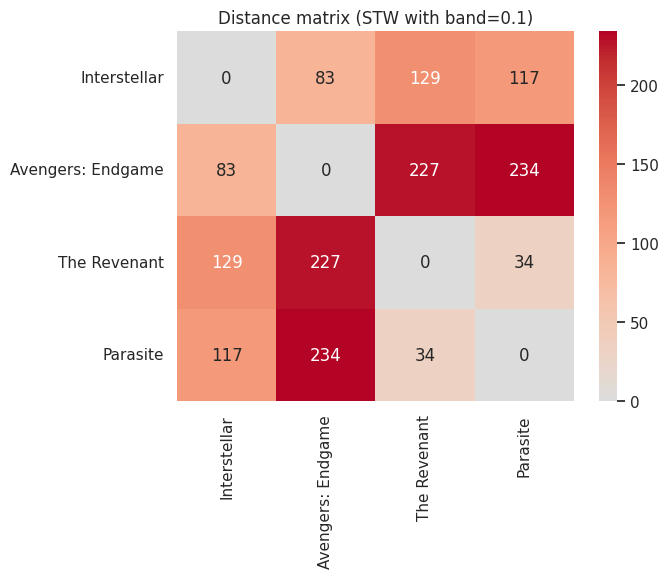

In [15]:
band = .1

dtw = DtwDist(window=band)
sns.heatmap(dtw.transform(data), cmap='coolwarm', center=0, annot=True, fmt='.0f', xticklabels=movies, yticklabels=movies, )
plt.title(f'Distance matrix (STW with band={band})')

In [16]:
aligner = AlignerDtwNumba(window=band)

In [17]:
def plot_alignments(idx1, idx2):
    ts1, ts2 = data.loc[idxs[idx1]], data.loc[idxs[idx2]]
    aligner.fit([ts1, ts2])
    alignments = aligner.get_alignment()
    plt.plot(ts1, c="C0", label=movies[idx1])
    plt.plot(ts2, c="C1", label=movies[idx2])
    for _, row in alignments.iterrows():
        ind0 = row['ind0']
        ind1 = row['ind1']
        plt.plot([ind0, ind1], [ts1.iloc[ind0], ts2.iloc[ind1]], color='gray', linestyle='--', linewidth=0.5)
    plt.legend()
    plt.show()

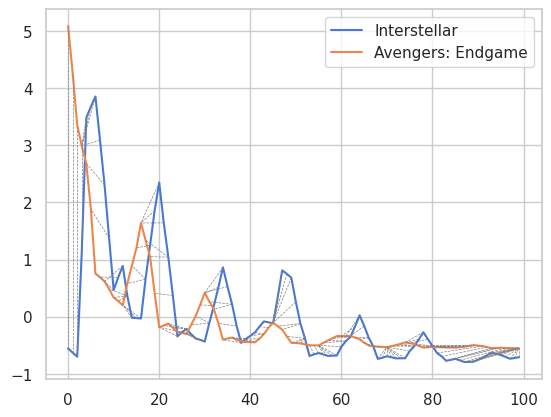

In [18]:
plot_alignments(0, 1)

## Distance Matrix

In [19]:
import numpy as np

We compute the distance matrix in order to estimate dbscan parameters and to use in hierarchical clustering.

In [20]:
%%time
pipeline  = scaler * dtw
dist_matrix = pipeline.transform(train_X)

CPU times: user 18.7 s, sys: 45.1 ms, total: 18.7 s
Wall time: 18.7 s


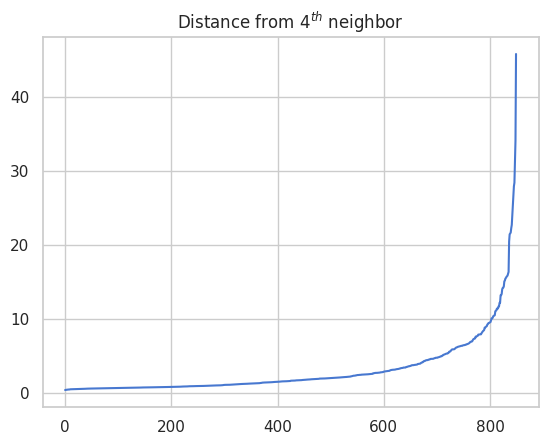

In [21]:
k = 4
distances = []

for d in dist_matrix:
    sorted_indexes = np.argsort(d)
    distances.append(d[sorted_indexes[k]])

plt.plot(range(len(distances)), sorted(distances))
plt.title(r'Distance from $%s^{th}$ neighbor'%k)
plt.show()

## Kmeans

In [22]:
kmeans = TimeSeriesKMeans(n_clusters=2, metric='dtw',
                          distance_params=dict(window=band))

In [23]:
pipeline = scaler * kmeans

In [24]:
%%time
pipeline.fit(train_X)

CPU times: user 9.32 s, sys: 82 ms, total: 9.4 s
Wall time: 9.4 s


ClustererPipeline(clusterer=TimeSeriesKMeans(distance_params={'window': 0.1},
                                             n_clusters=2),
                  transformers=[TabularToSeriesAdaptor(transformer=StandardScaler())])

In [25]:
labels = pipeline.clusterer_.labels_

In [26]:
import numpy as np
np.unique(labels, return_counts=True)

(array([0, 1]), array([691, 159]))

In [27]:
train['kmeans'] = labels
train_X_norm['kmeans'] = pd.Categorical(train_X_norm.index.get_level_values(0).map(train['kmeans']))

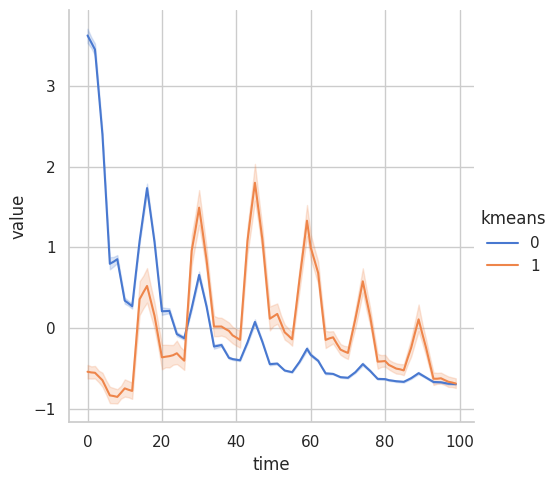

In [28]:
sns.relplot(train_X_norm, x='time', y='value', kind='line', hue='kmeans')


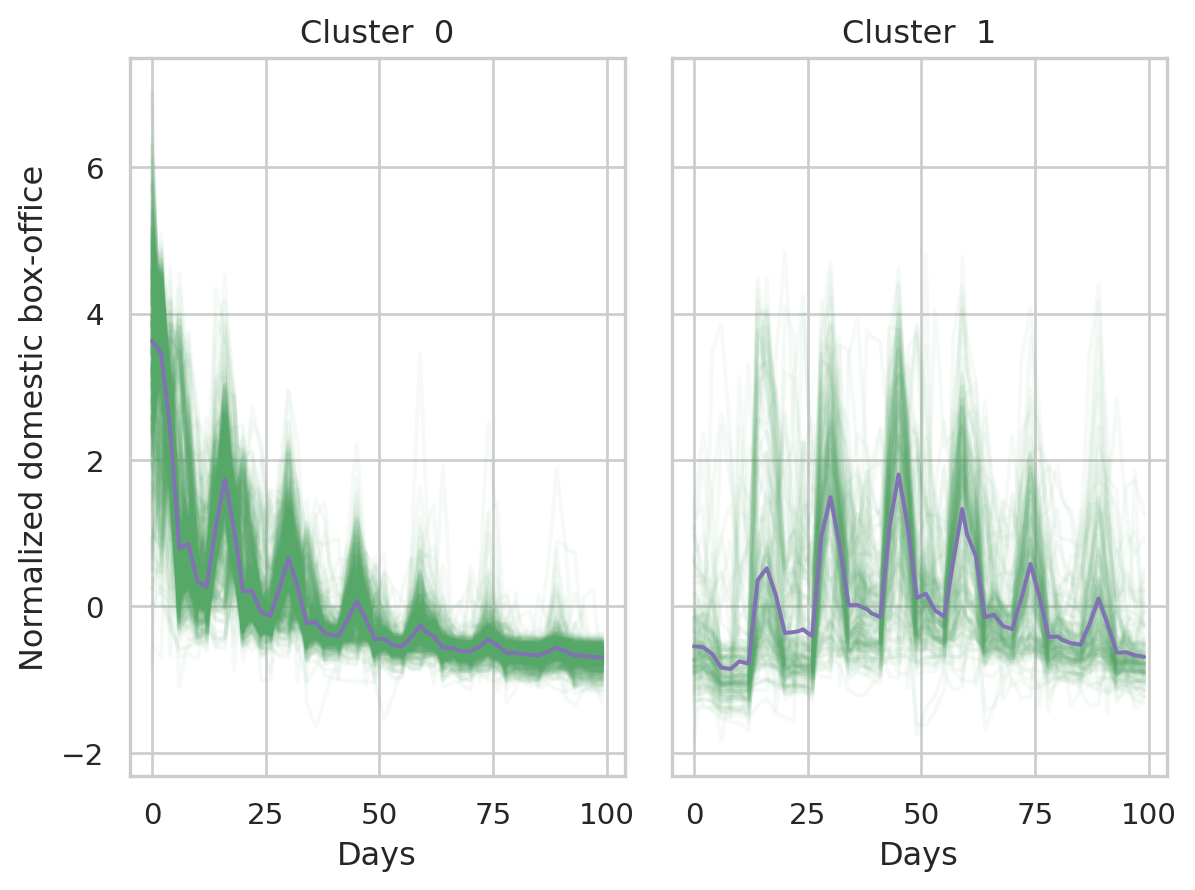

In [29]:
(
    so.Plot(train_X_norm, x='time', y='value')
    .facet(col='kmeans')
    .add(so.Lines(alpha=.05, color='C2'), group='id')
    .add(so.Line(color='C4'), so.Agg(func='mean'))
    .label(x='Days', y='Normalized domestic box-office', col='Cluster ')
)

This is more or less the same pattern we found in during data understanding.

In [30]:
print("Silhouette score:", silhouette_score(dist_matrix, labels, metric='precomputed'))

Silhouette score: 0.8499607983102749


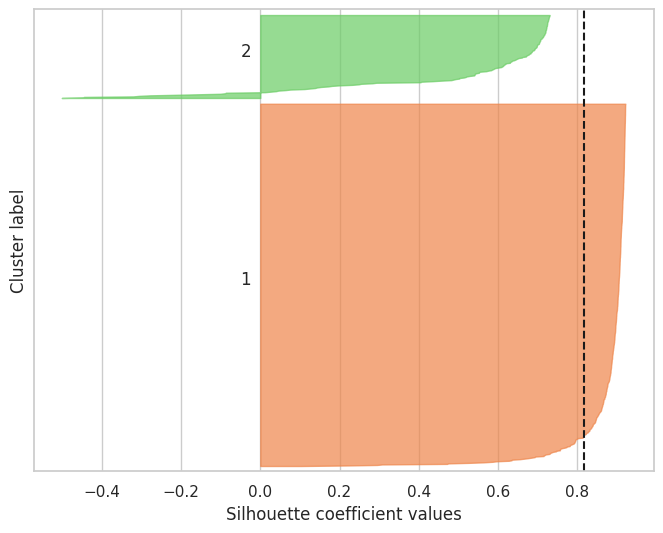

In [31]:
fig, ax = plt.subplots()
fig.set_size_inches((8, 6))
plot_silhouette(dist_matrix, cluster_labels=labels + 1, ax=ax)

## DBSCAN

We run dbscan and hierarchical clustering on a precomputed matrix using sklearn clusterers even though it is slower (?), because we can't be bothered with sktime release schedule.

In [32]:
dbscan = DBSCAN(eps=10, min_samples=4, metric='precomputed', n_jobs=-1)

In [33]:
%%time
dbscan.fit(dist_matrix)

CPU times: user 112 ms, sys: 1.01 ms, total: 113 ms
Wall time: 17.4 ms


,eps,10
,min_samples,4
,metric,'precomputed'
,metric_params,None
,algorithm,'auto'
,leaf_size,30
,p,None
,n_jobs,-1


In [34]:
np.unique(dbscan.labels_, return_counts=True)

(array([-1,  0,  1]), array([ 25, 821,   4]))

In [35]:
train['dbscan'] = dbscan.labels_
train_X_norm['dbscan'] = pd.Categorical(train_X_norm.index.get_level_values(0).map(train['dbscan']))

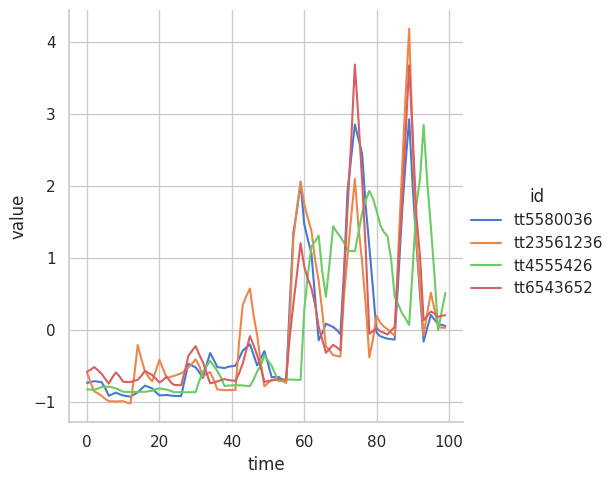

In [36]:
sns.relplot(train_X_norm[train_X_norm['dbscan'] == 1], x='time', y='value', kind='line', hue='id')

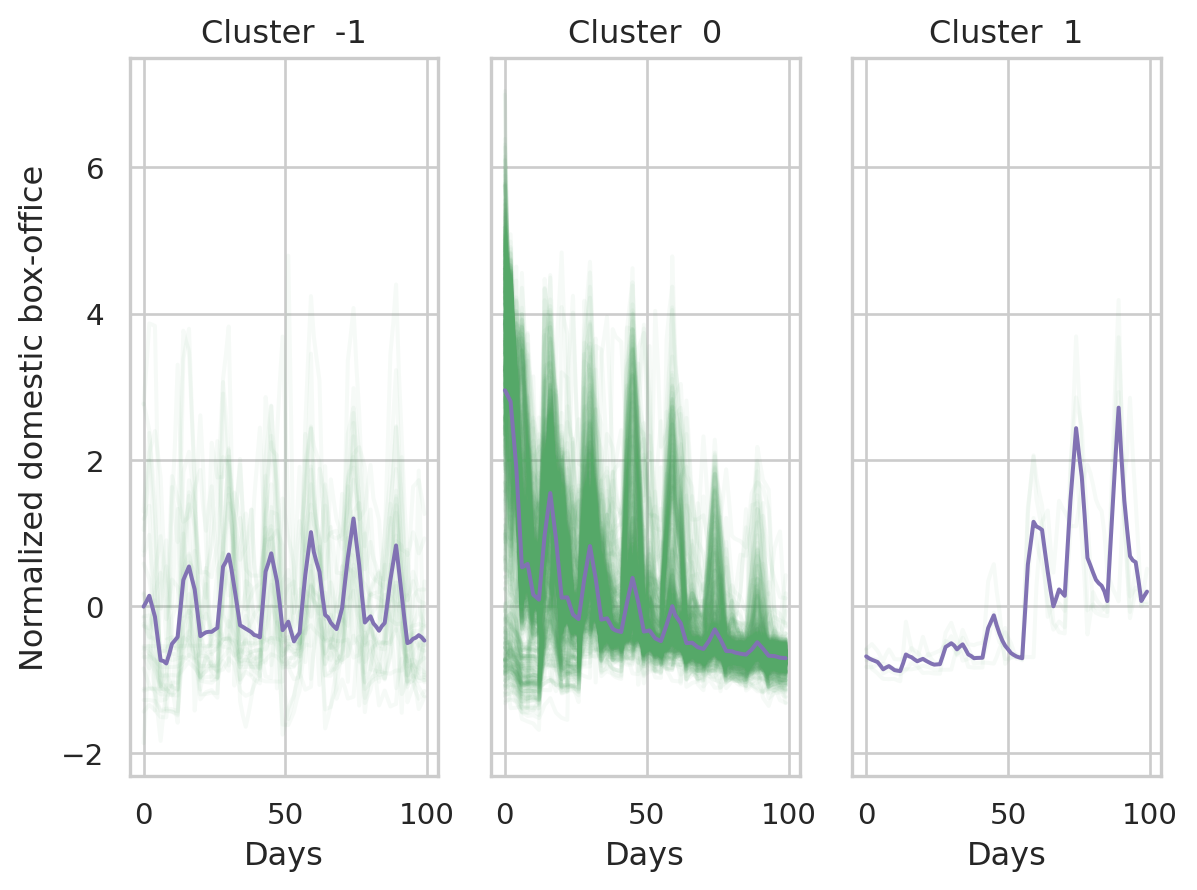

In [37]:
(
    so.Plot(train_X_norm, x='time', y='value')
    .facet(col='dbscan')
    .add(so.Lines(alpha=.05, color='C2'), group='id')
    .add(so.Line(color='C4'), so.Agg(func='mean'))
    .label(x='Days', y='Normalized domestic box-office', col='Cluster ')
)

## Hierarchical clustering

We attempt to create a clustering with single, average and complete link: the best dendrogram is obtained with complete linkage.

In [38]:
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster

In [39]:
def get_linkage_matrix(model):
    # Create linkage matrix

    # create the counts of samples under each node
    counts = np.zeros(model.children_.shape[0])
    n_samples = len(model.labels_)
    for i, merge in enumerate(model.children_):
        current_count = 0
        for child_idx in merge:
            if child_idx < n_samples:
                current_count += 1  # leaf node
            else:
                current_count += counts[child_idx - n_samples]
        counts[i] = current_count

    linkage_matrix = np.column_stack(
        [model.children_, model.distances_, counts]
    ).astype(float)

    return linkage_matrix

def plot_dendrogram(model, **kwargs):
    linkage_matrix = get_linkage_matrix(model)
    dendrogram(linkage_matrix, **kwargs)

In [40]:
hier_clust = AgglomerativeClustering(metric='precomputed', n_clusters=None, distance_threshold=0, linkage='complete')

In [41]:
%%time
hier_clust.fit(dist_matrix)

CPU times: user 24.7 ms, sys: 1.92 ms, total: 26.7 ms
Wall time: 24.3 ms


,n_clusters,None
,metric,'precomputed'
,memory,None
,connectivity,None
,compute_full_tree,'auto'
,linkage,'complete'
,distance_threshold,0
,compute_distances,False


In [42]:
threshold = 200

([], [])

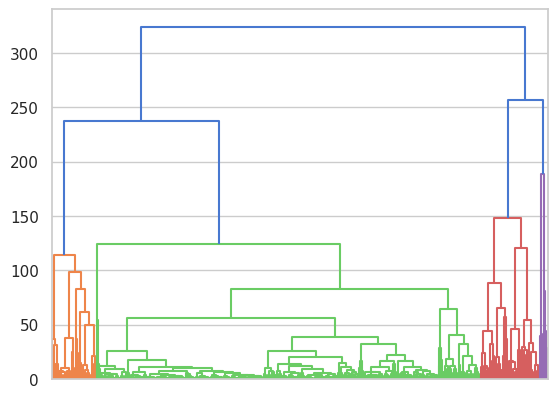

In [43]:
plot_dendrogram(hier_clust, color_threshold=threshold)
plt.xticks([], [])

In [44]:
linkage_matrix = get_linkage_matrix(hier_clust)
labels = fcluster(linkage_matrix, criterion='distance', t=threshold)

In [45]:
np.unique(labels, return_counts=True)

(array([1, 2, 3, 4], dtype=int32), array([ 76, 658, 101,  15]))

In [46]:
print("Silhouette score:", silhouette_score(dist_matrix, labels, metric='precomputed'))

Silhouette score: 0.7692047613528188


In [47]:
train['hier'] = pd.Categorical(labels)
train_X_norm['hier'] = train_X_norm.index.get_level_values(0).map(train['hier'])

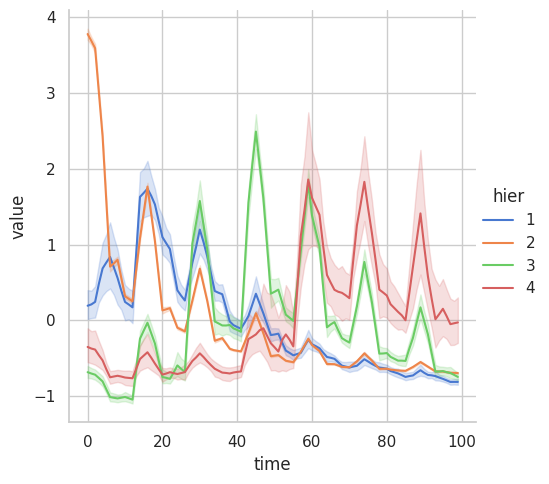

In [48]:
sns.relplot(train_X_norm, x='time', y='value', kind='line', hue='hier')

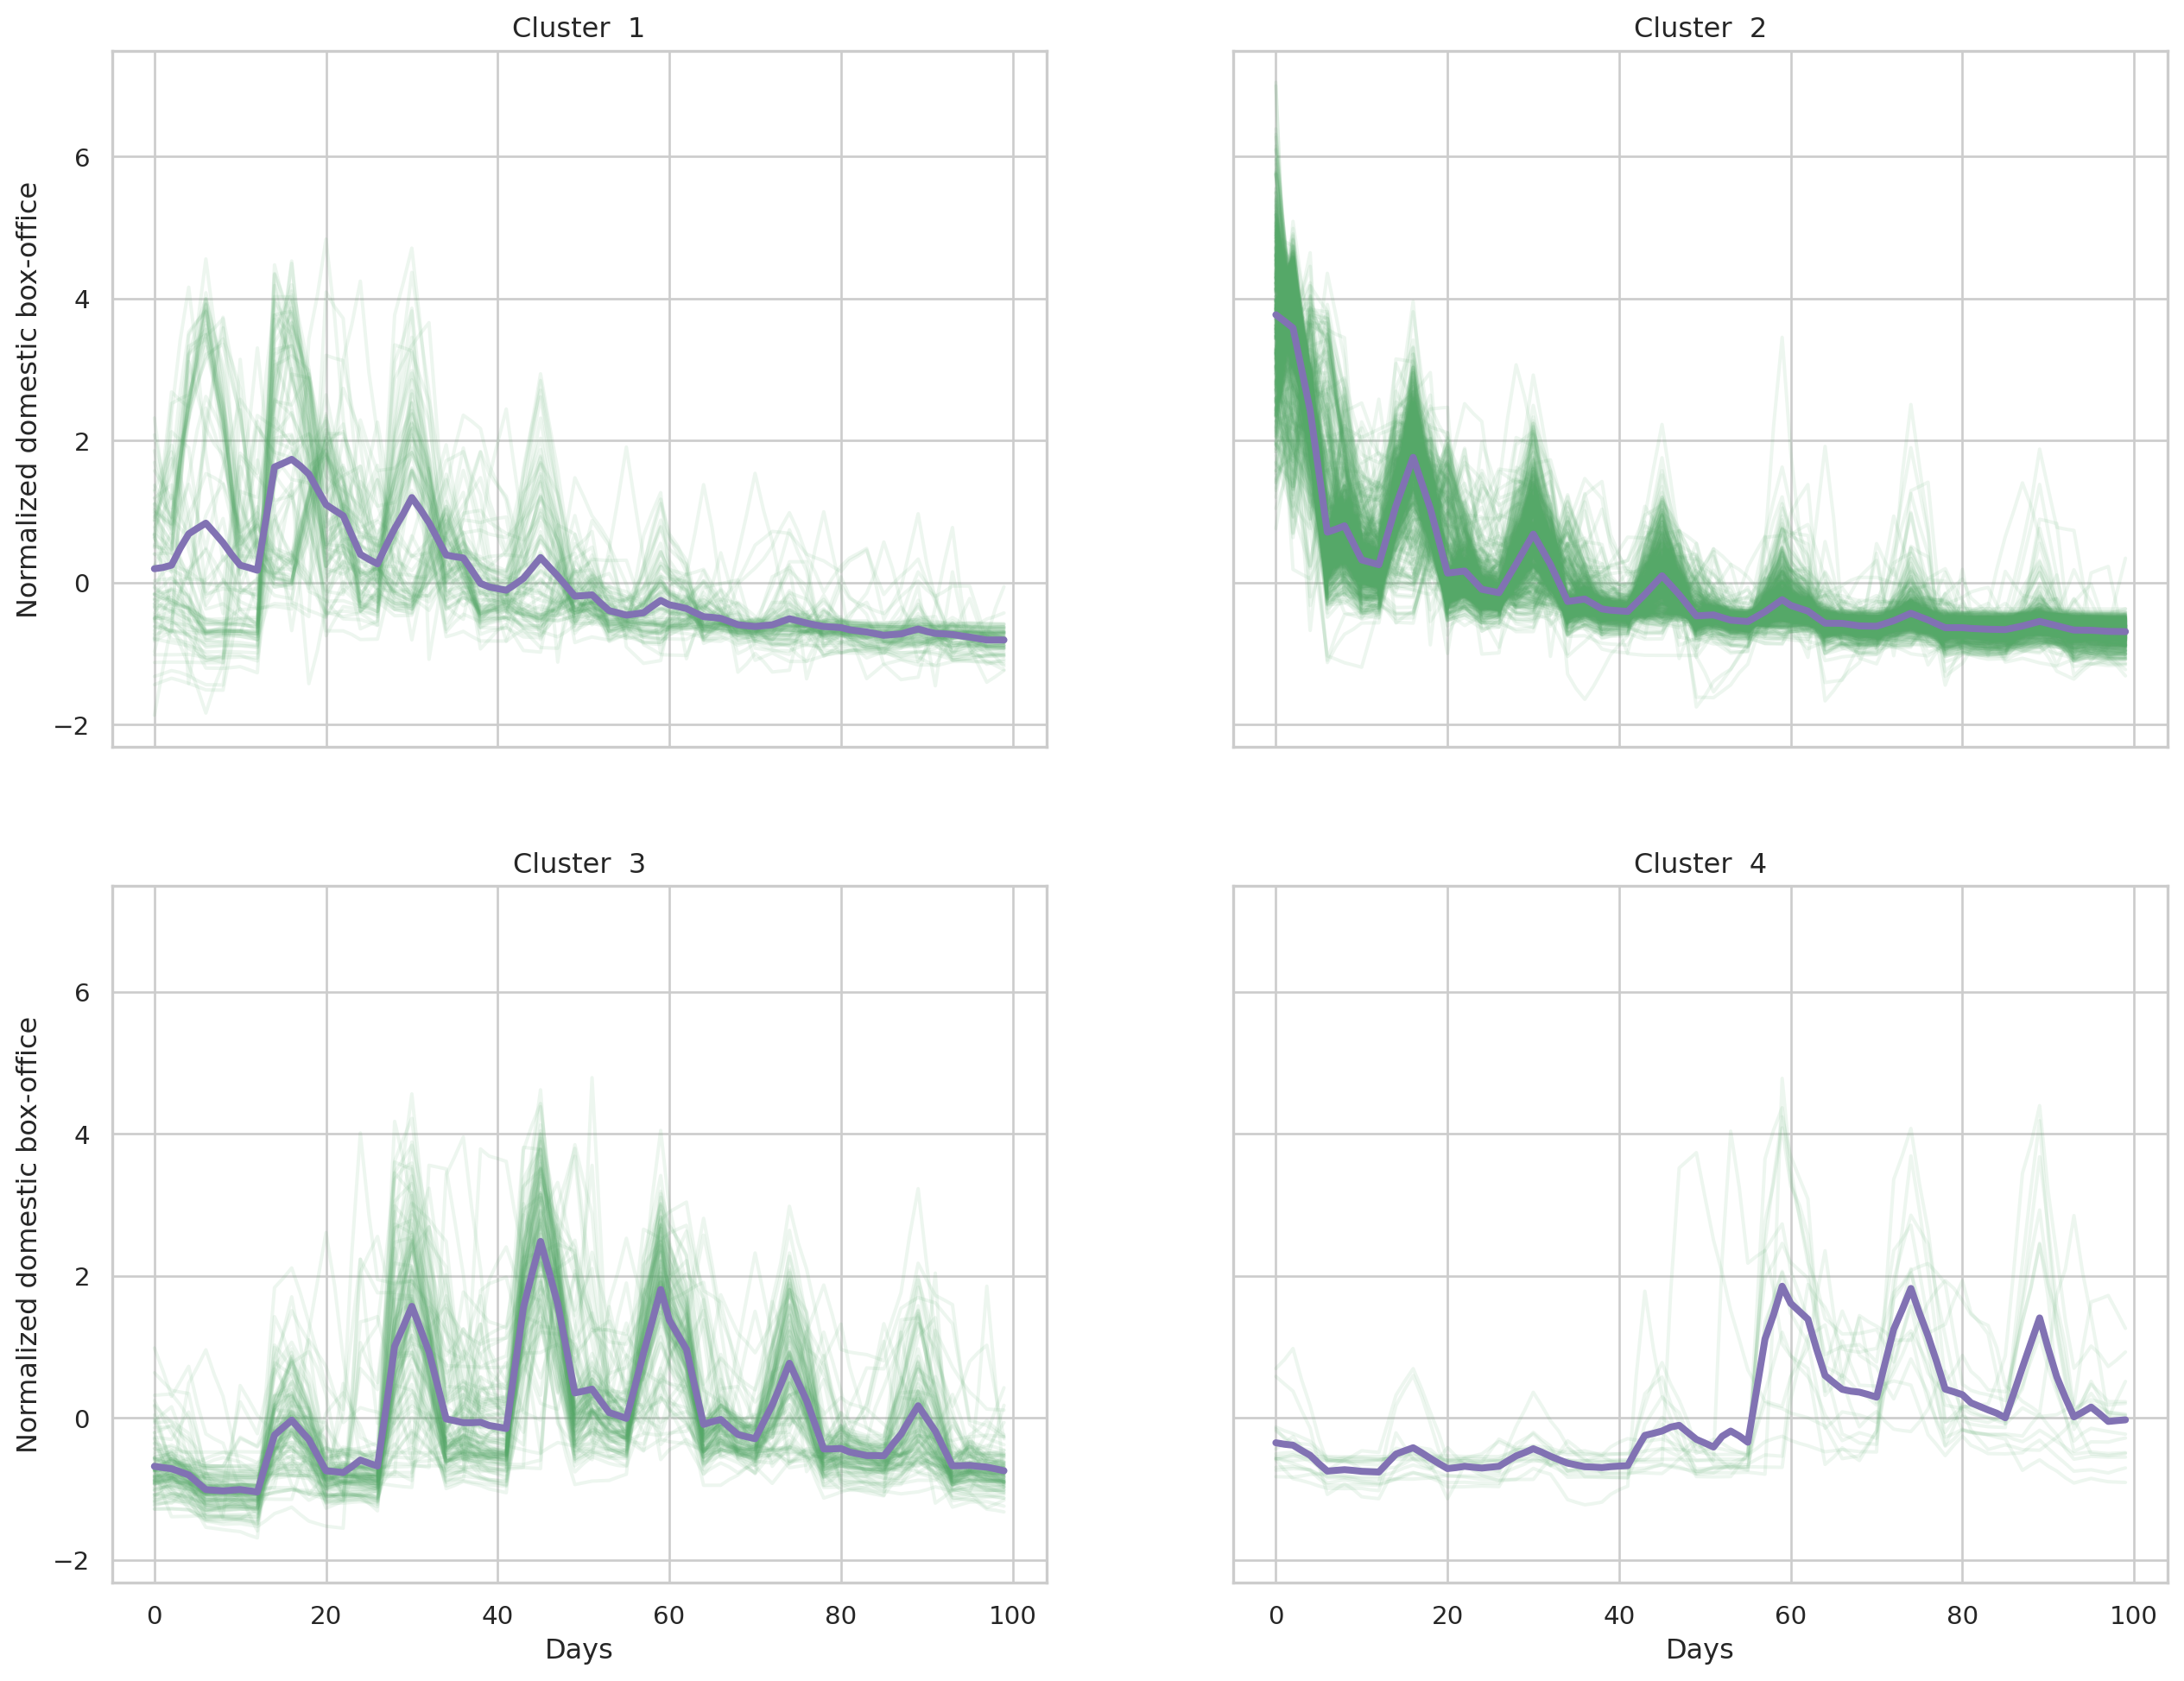

In [49]:
f = plt.Figure(figsize=(16, 12))
(
    so.Plot(train_X_norm, x='time', y='value')
    .facet(col='hier', wrap=2)
    .add(so.Lines(alpha=.1, color='C2'), group='id')
    .add(so.Line(color='C4', linewidth=3), so.Agg(func='mean'))
    .label(x='Days', y='Normalized domestic box-office', col='Cluster ')
    .on(f)
)

In [ ]:
def get_medoids(dist_matrix, labels):
    medoids = []
    dist_matrix_df = pd.DataFrame(dist_matrix, index=train.index.get_level_values(0), columns=train.index.get_level_values(0))
    grouped = dist_matrix_df.groupby(labels)
    for _, group in grouped:
        medoids.append(group[group.index].sum(axis=0).idxmin())
    return medoids

In [51]:
medoids = get_medoids(dist_matrix, labels)
movies = list(train.loc[medoids, 'title'])
movies

['The Wandering Earth',
 'Mad Max: Fury Road',
 '12 Years a Slave',
 'The Danish Girl']

In [52]:
train.loc[medoids]

,title,startYear,runtimeMinutes,numVotes,countryOfOrigin,awardsOrNominations,awards,nominations,rating,genre,...,93,94,95,96,97,98,99,kmeans,dbscan,hier
id,,,,,,,,,,,,,,,,,,,,,
tt7605074,The Wandering Earth,2019,125,38453,['CN'],True,39.0,40.0,5.9,"['Action', 'Adventure', 'Sci-Fi']",...,1659.0,2056.0,2413.0,2081.0,1818.0,1399.0,949.0,0,0,1
tt1392190,Mad Max: Fury Road,2015,120,1177539,"['AU', 'US']",True,245.0,234.0,8.1,"['Action', 'Adventure', 'Sci-Fi']",...,242233.0,243773.0,245481.0,209339.0,178396.0,197961.0,217511.0,0,0,2
tt2024544,12 Years a Slave,2013,134,770412,"['GB', 'US']",True,244.0,338.0,8.1,"['Biography', 'Drama', 'History']",...,158756.0,179126.0,201277.0,188885.0,176761.0,178445.0,180084.0,1,0,3
tt0810819,The Danish Girl,2015,119,204330,"['GB', 'US', 'DE', 'DK', 'BE', 'JP']",True,32.0,82.0,7.1,"['Biography', 'Drama']",...,91727.0,99937.0,112969.0,112714.0,112374.0,117609.0,121652.0,1,-1,4


Visualization of cluster medoids.

In [53]:
def get_title(idx):
    return train.loc[idx, 'title'] + ' ' + str(train.loc[idx, 'startYear'])

def get_plot_title(idx):
    idx = int(idx)
    df = train.loc[medoids].set_index('hier')
    return f"Cluster{idx}\n" + df.loc[idx, 'title'] + ' ' + str(df.loc[idx, 'startYear'])

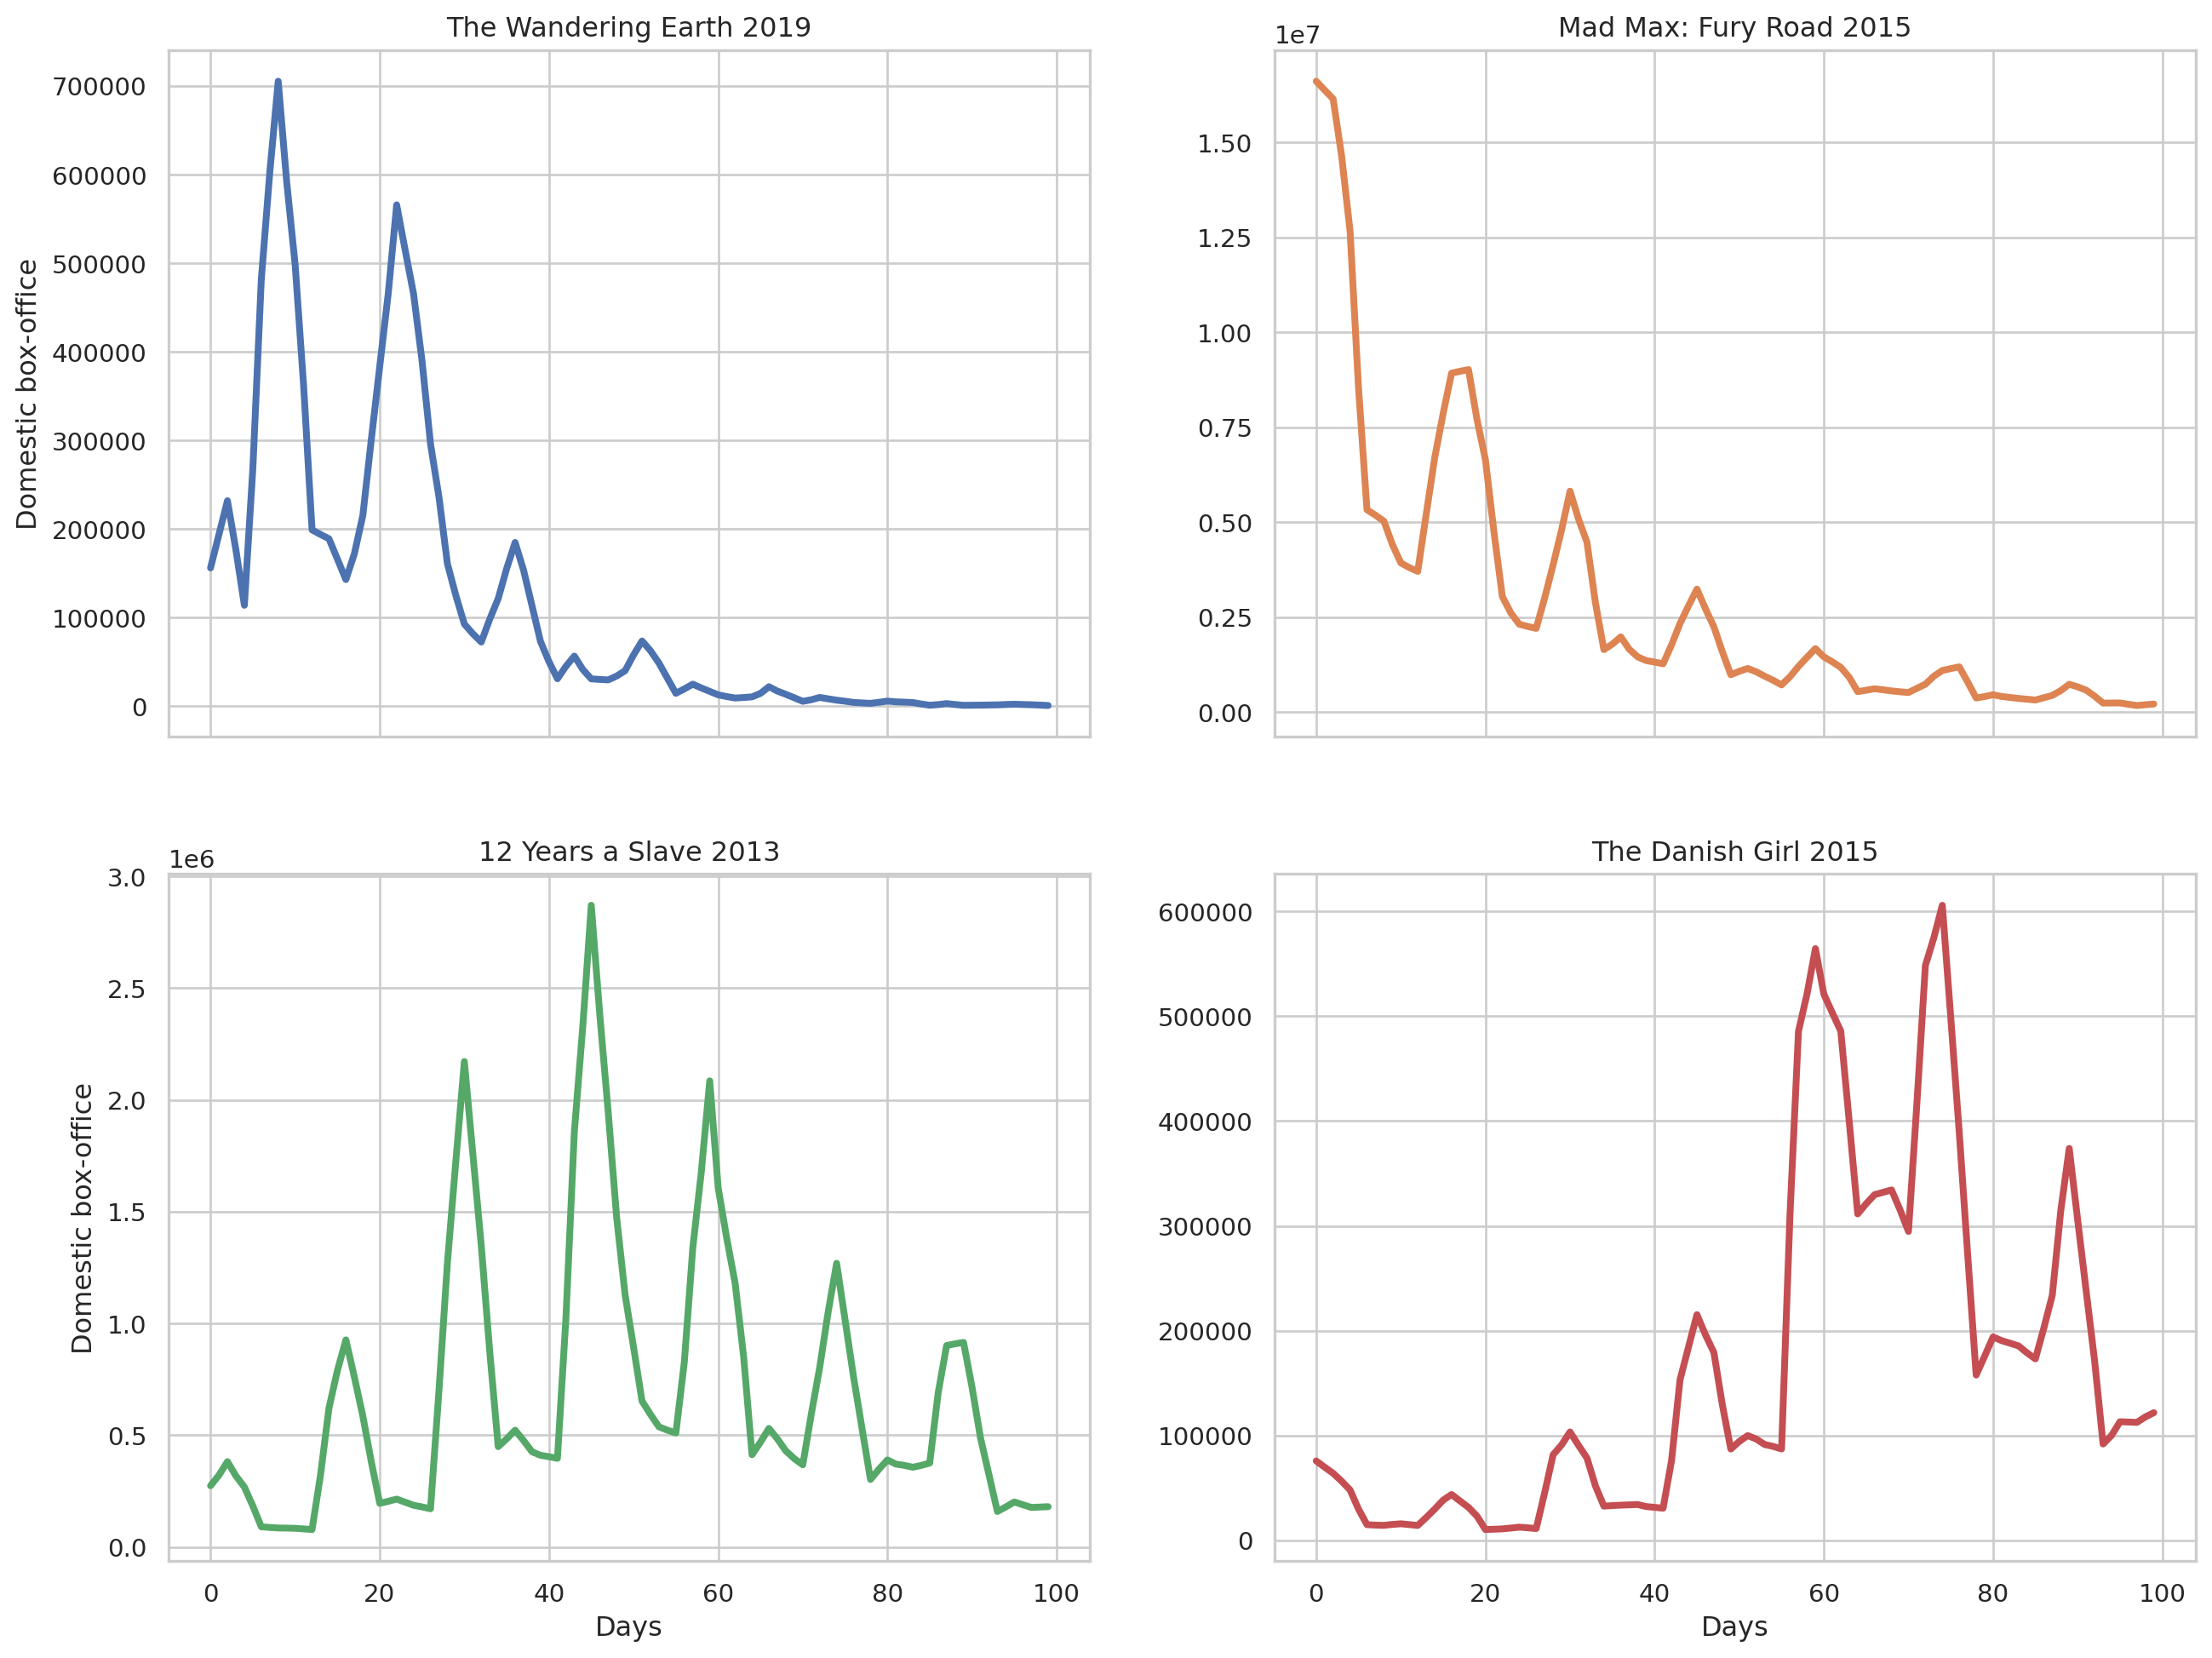

In [54]:
f = plt.Figure(figsize=(16, 12))
(
    so.Plot(train_X.loc[medoids], x='time', y='value')
    .facet(col='id', wrap=2)
    .add(so.Lines(linewidth=3), color='id', legend=False)
    .label(x='Days', y='Domestic box-office', title=get_title)
    .share(y=False)
    .on(f)
)

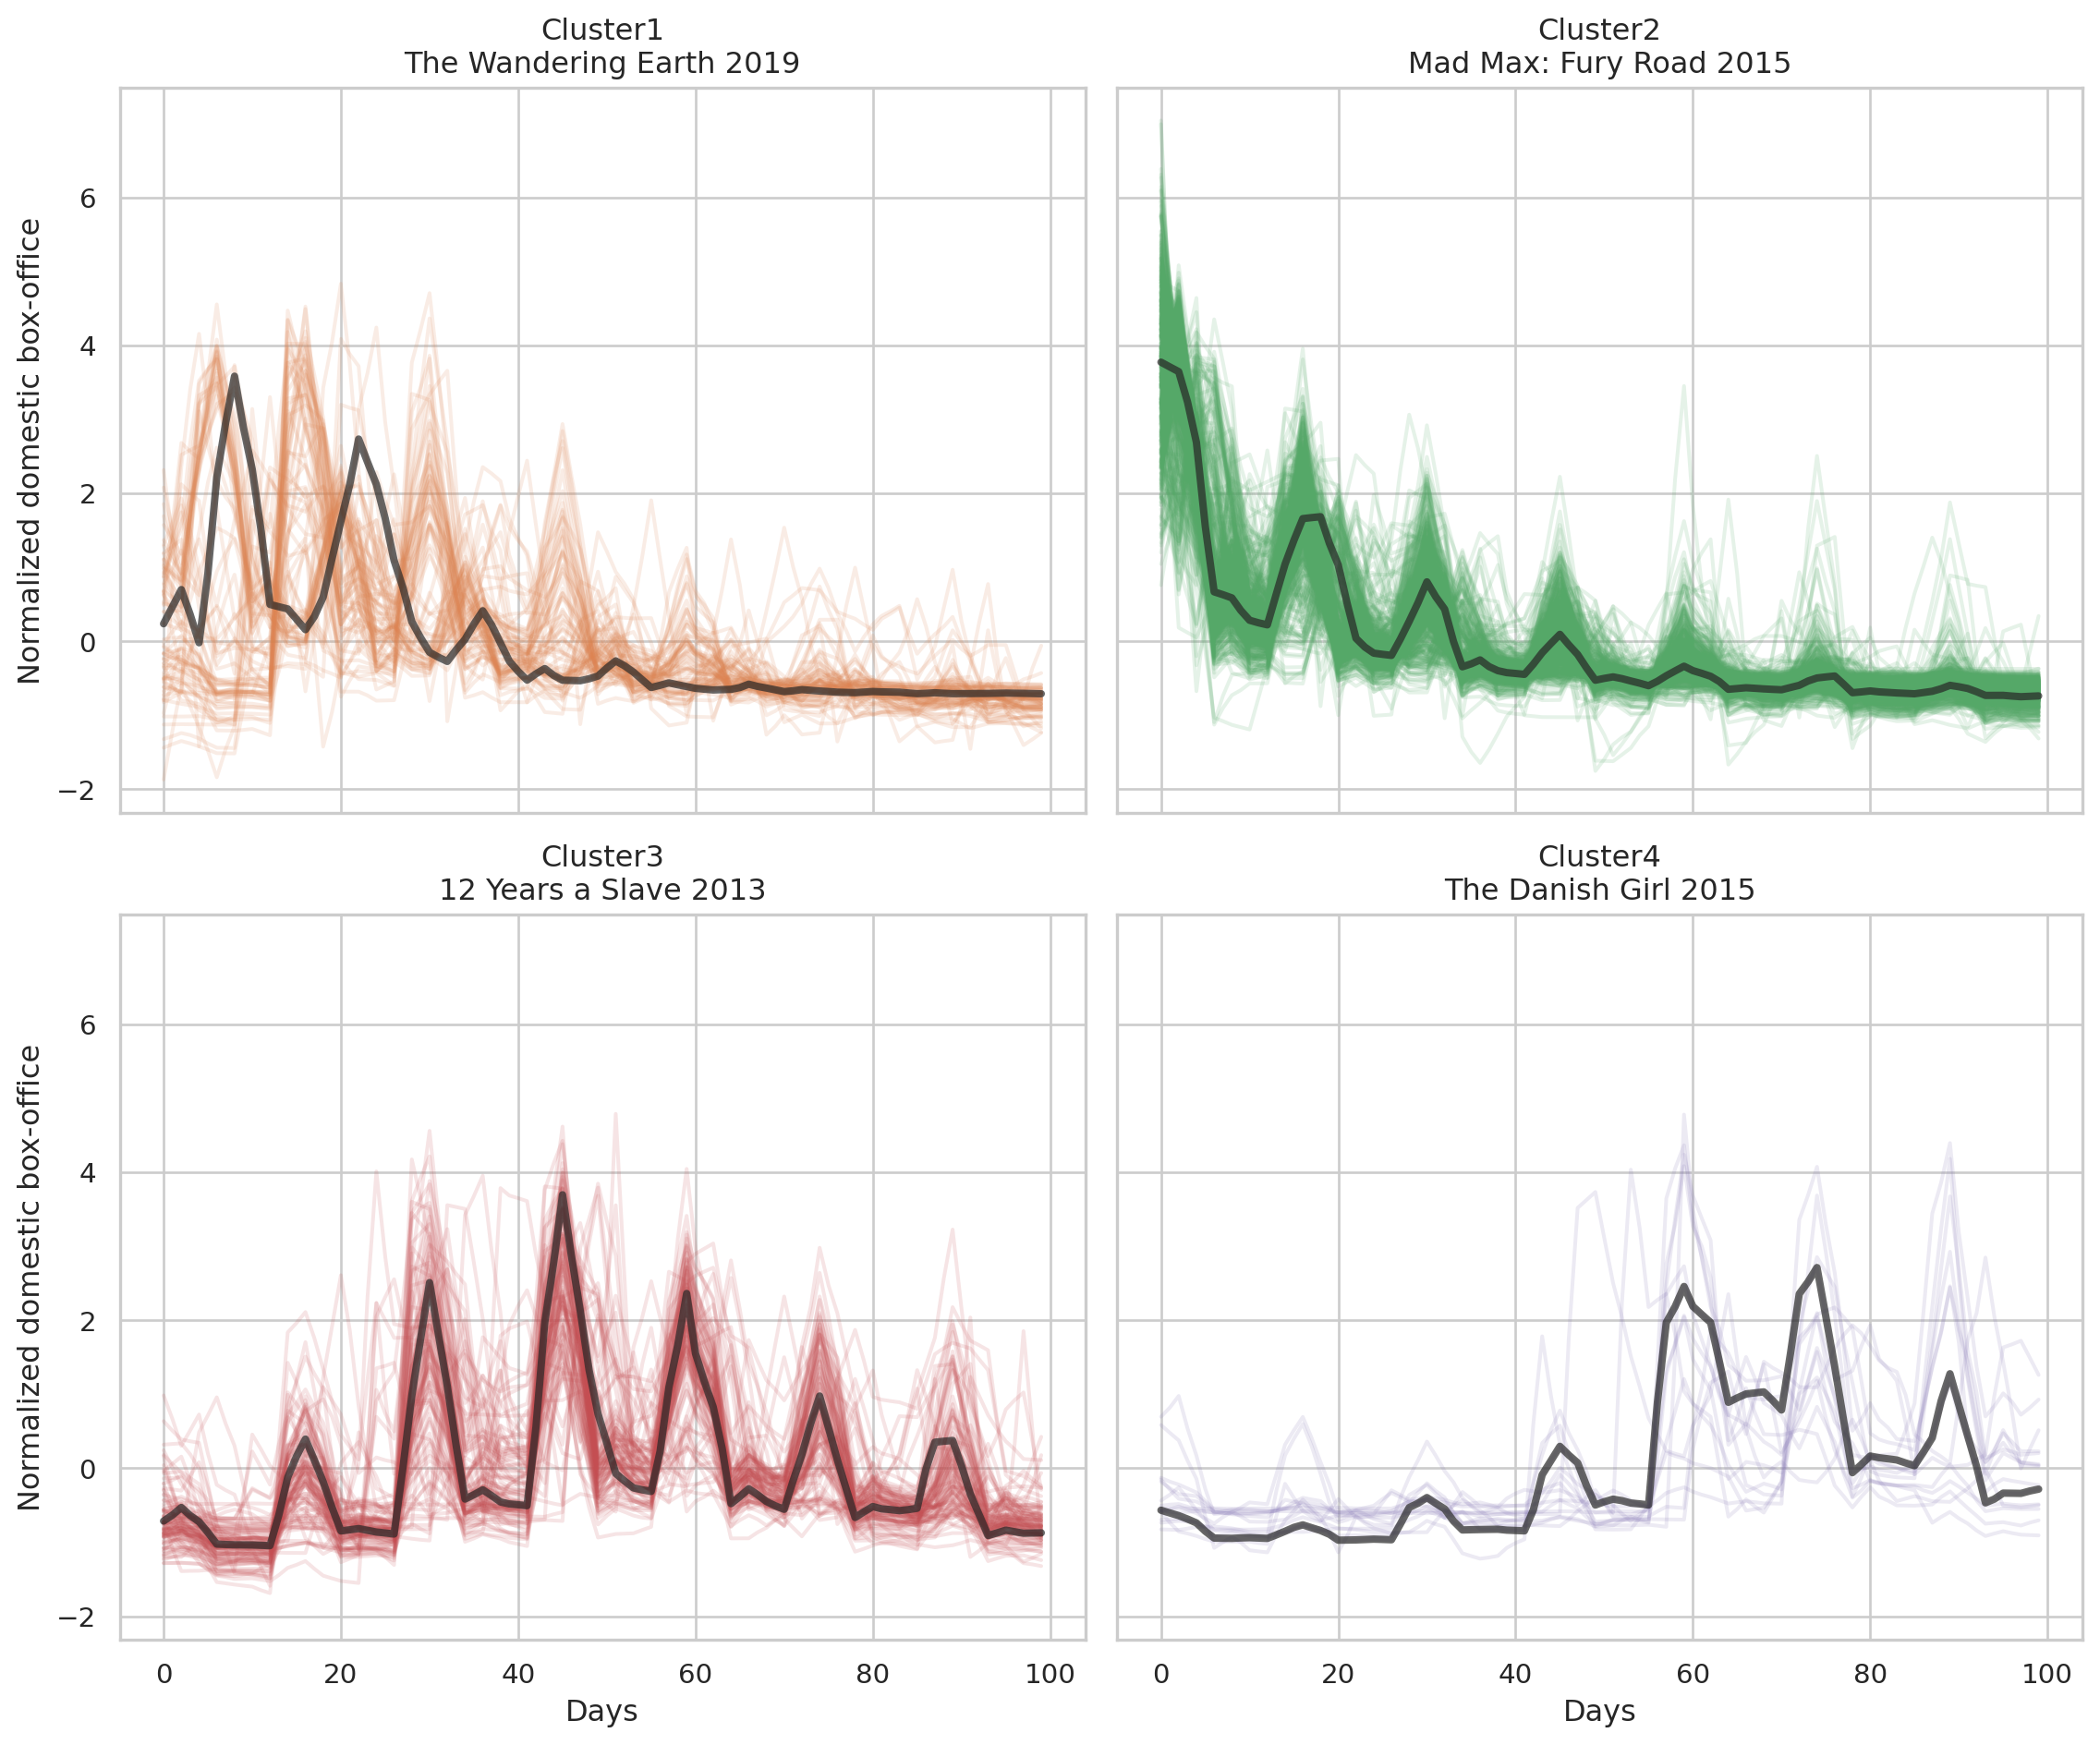

In [55]:
(
    so.Plot(train_X_norm, x='time', y='value')
    .facet(col='hier', wrap=2)
    .add(so.Lines(alpha=.15), group='id', color='hier', legend=False)
    .add(so.Lines(linewidth=3, color='k', alpha=.7), data=train_X_norm.loc[medoids])
    .label(x='Days', y='Normalized domestic box-office', title=get_plot_title)
    # Use the same colors as the dendrogram
    .scale(color=so.Nominal(('C1', 'C2', 'C3', 'C4'), order=(1, 2, 3, 4)))
    .layout(size=(12, 10))
)

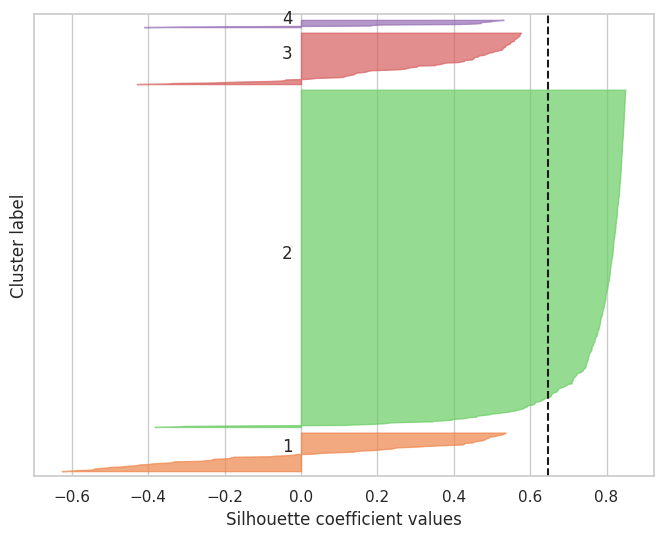

In [56]:
fig, ax = plt.subplots()
fig.set_size_inches((8, 6))
plot_silhouette(dist_matrix, cluster_labels=labels, ax=ax)

Silhouette scores for cluster 2 records are carrying the mean. While silhouette of records in cluster 3 is still good, many records from cluster 1 and 4 have a negative silhouette score, suggesting that they were assigned to the wrong cluster. 

### sub-clusters of cluster 1

In [57]:
labels = fcluster(linkage_matrix, criterion='distance', t=110)
np.unique(labels, return_counts=True)

(array([1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=int32),
 array([ 11,  65,   4, 654,  46,  24,  31,   6,   9]))

In [58]:
subcl_map = {1: '1a', 2: '1b'}
train['subcl'] = labels
train['subcl'] = train['subcl'].map(lambda x: subcl_map.get(x, pd.NA))
train_X_norm['subcl'] = pd.Categorical(train_X_norm.index.get_level_values(0).map(train['subcl']))

In [59]:
#  We are only interested in the first two medoids
subcl_medoids = get_medoids(dist_matrix, labels)[:2]
subcl_movies = list(train.loc[subcl_medoids, 'title'])
subcl_movies

['La Chimera', 'The Wandering Earth']

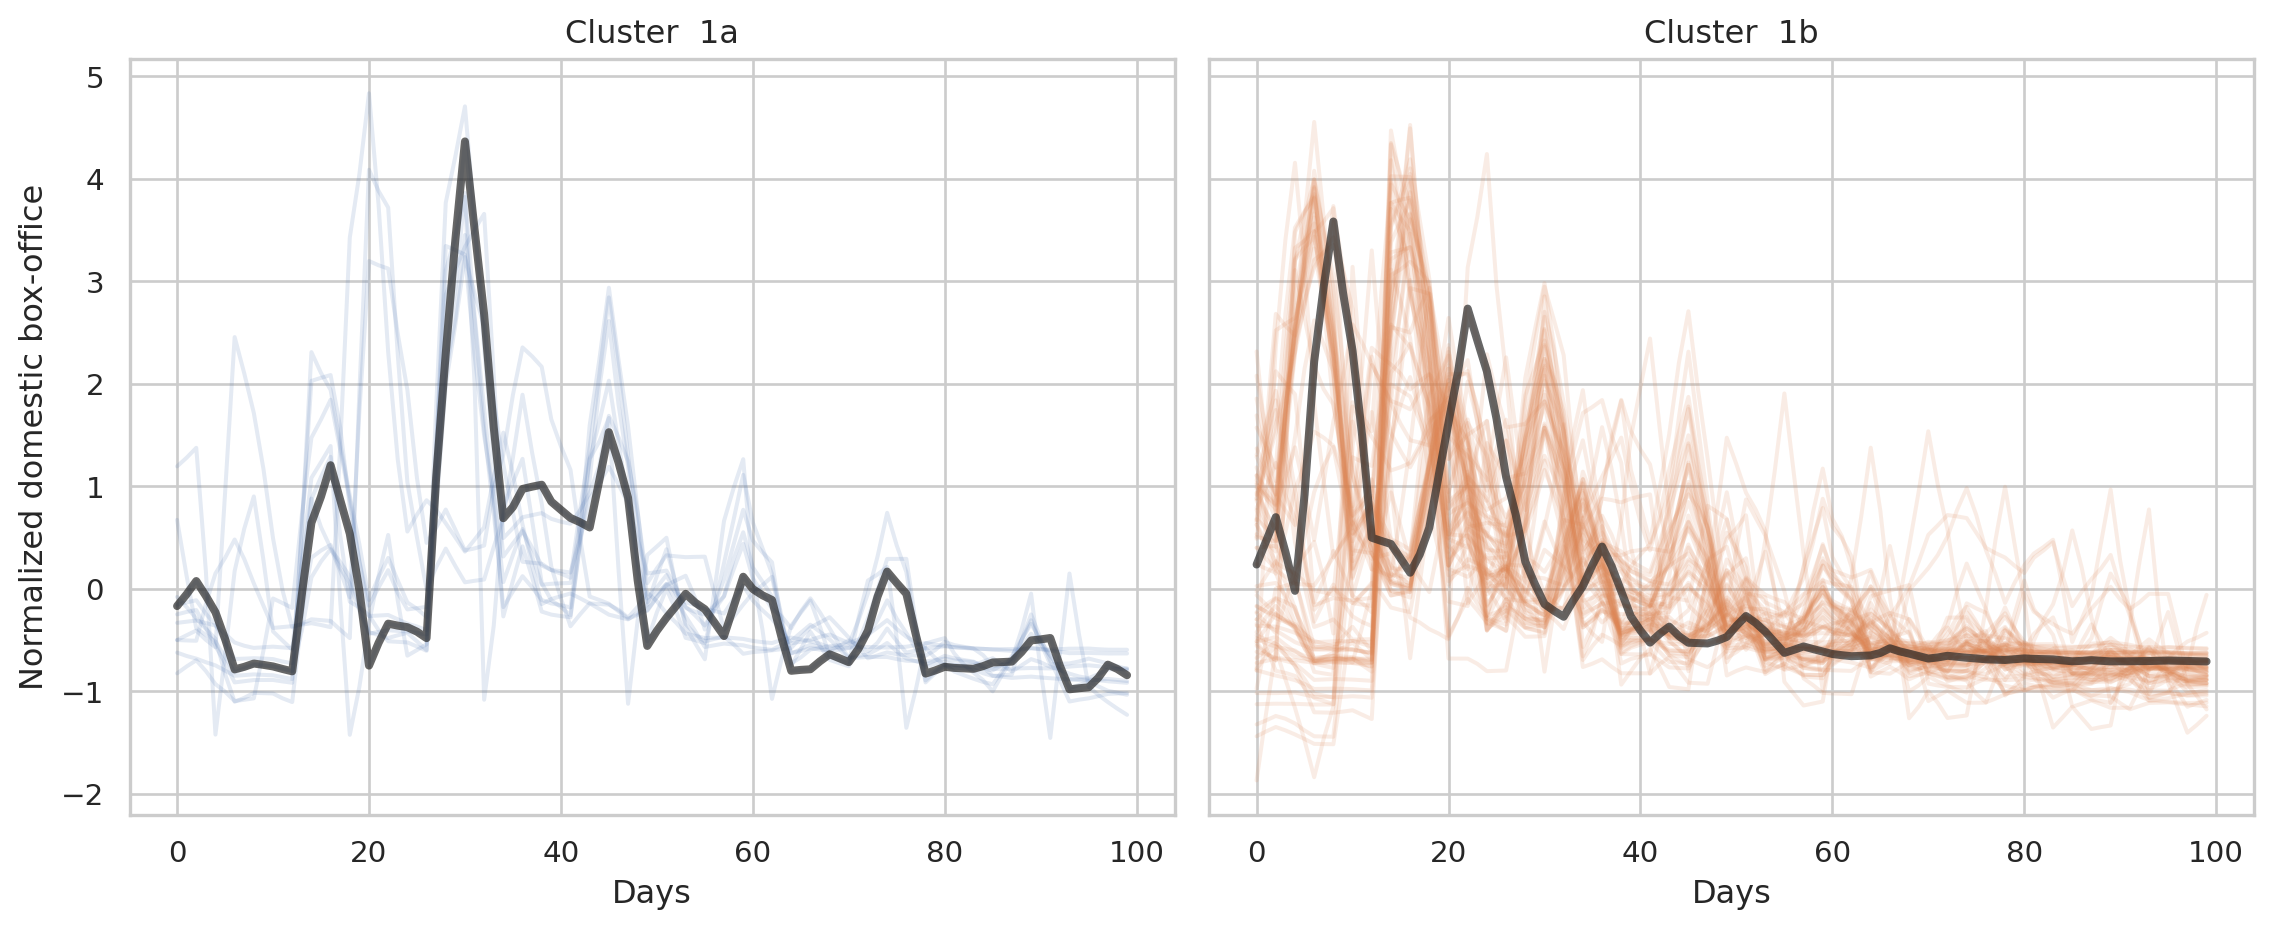

In [60]:
(
    so.Plot(train_X_norm, x='time', y='value')
    .facet(col='subcl', wrap=2)
    .add(so.Lines(alpha=.15), group='id', color='subcl', legend=False)
    .add(so.Lines(linewidth=3, color='k', alpha=.7), data=train_X_norm.loc[subcl_medoids])
    .label(x='Days', y='Normalized domestic box-office', col='Cluster ')
    .layout(size=(12, 5))
)

## Analysis of clusters

In [61]:
clustering = 'hier'

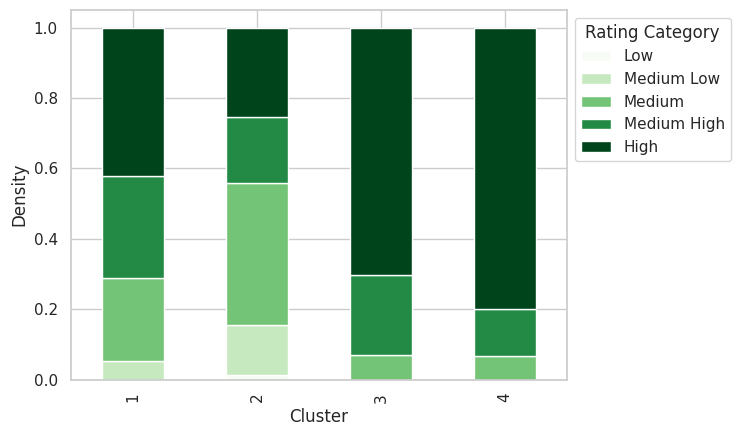

In [62]:
pd.crosstab(train[clustering], train['rating_category'], normalize='index').plot.bar(stacked=True, colormap='Greens')
plt.xlabel('Cluster')
plt.ylabel('Density')
plt.legend(title='Rating Category', bbox_to_anchor=(1, 1))

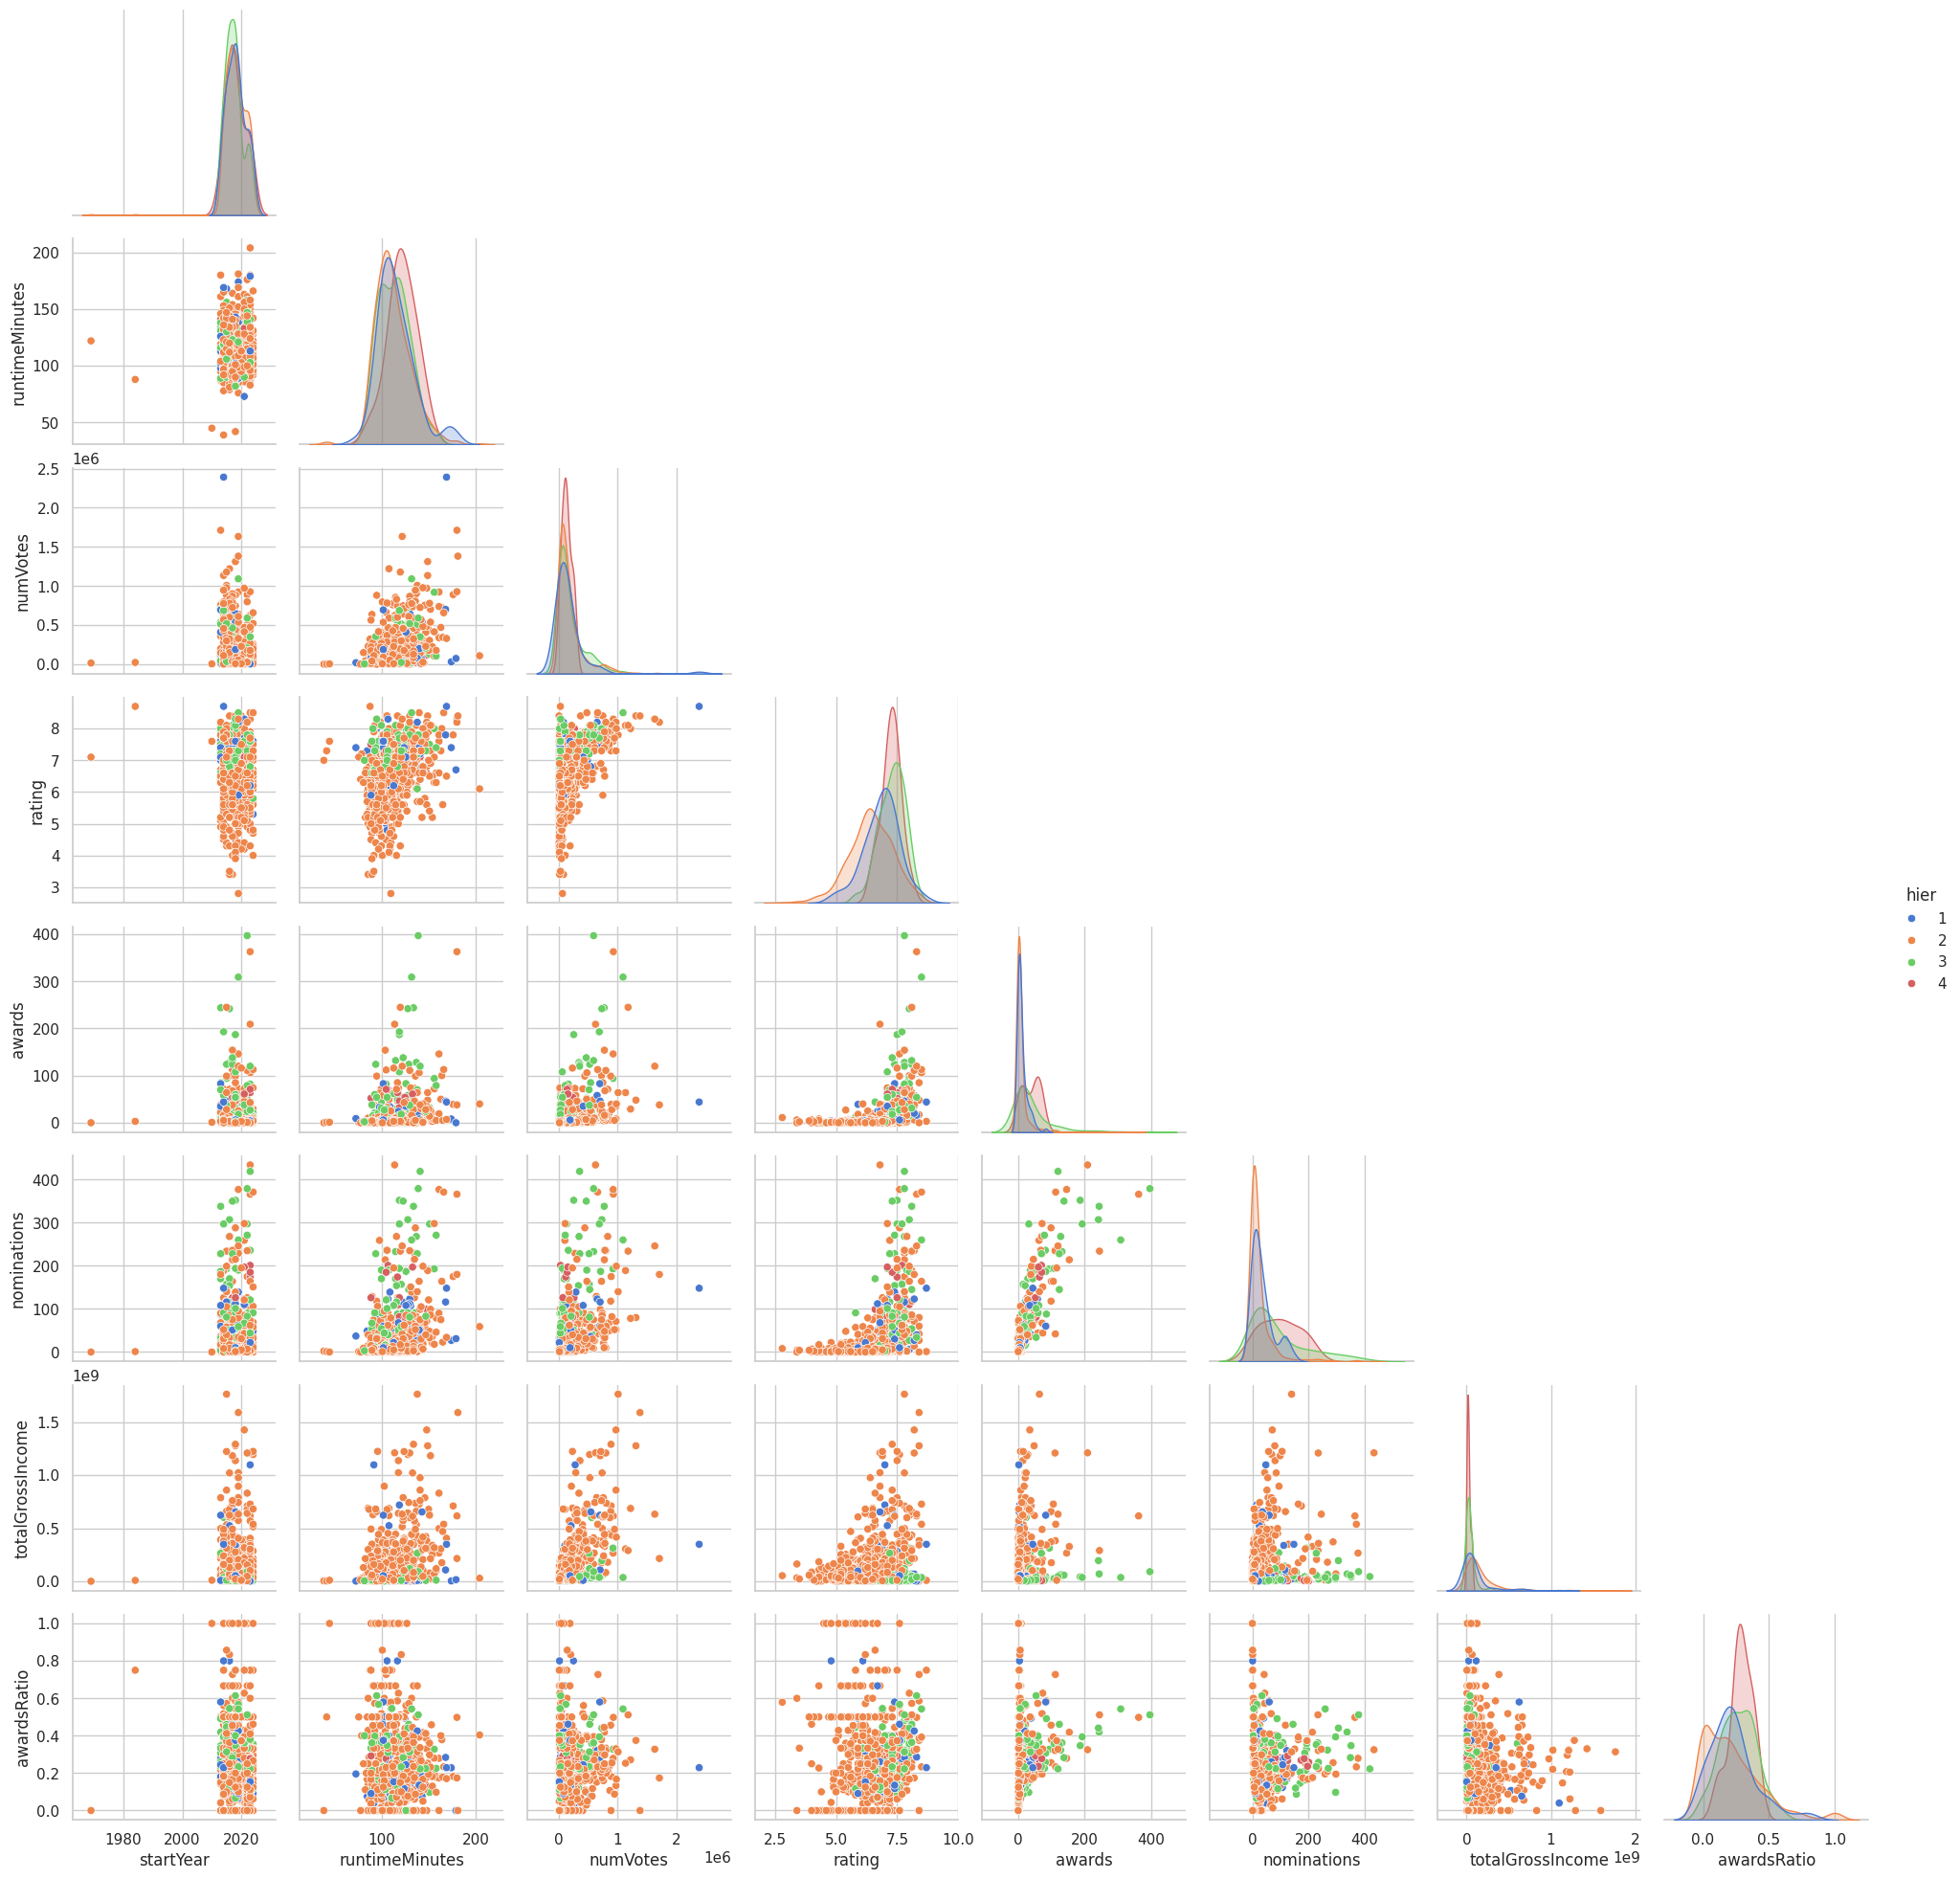

In [63]:
num_feats = ['startYear', 'runtimeMinutes', 'numVotes', 'rating', 'awards', 'nominations', 'totalGrossIncome', 'awardsRatio']
sns.pairplot(train, vars=num_feats, corner=True, hue='hier', diag_kws=dict(common_norm=False))

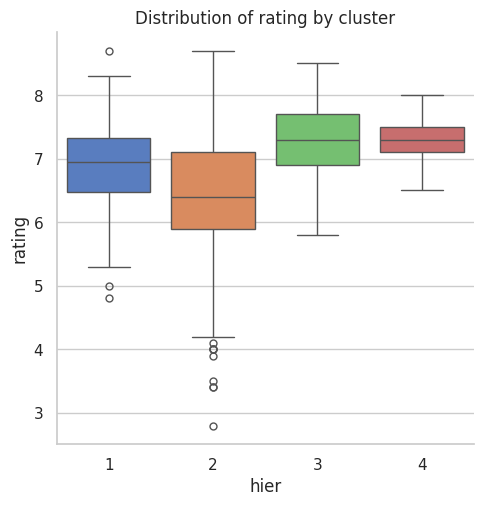

In [64]:
sns.catplot(train, x=clustering, y='rating', kind='box', hue=clustering, legend=False)
plt.title("Distribution of rating by cluster")
plt.show()

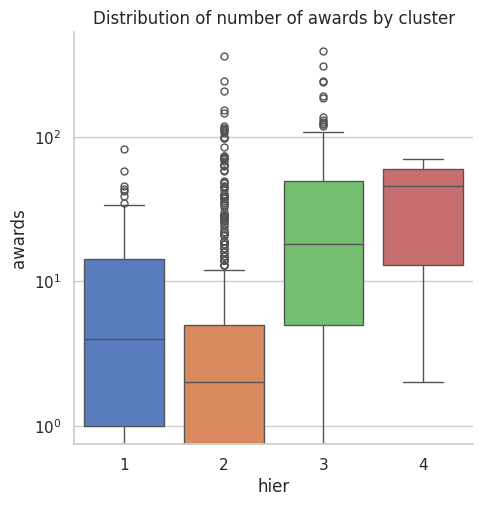

In [65]:
sns.catplot(train, x=clustering, y='awards', kind='box', hue=clustering, legend=False)
plt.title("Distribution of number of awards by cluster")
plt.yscale('log')
plt.show()

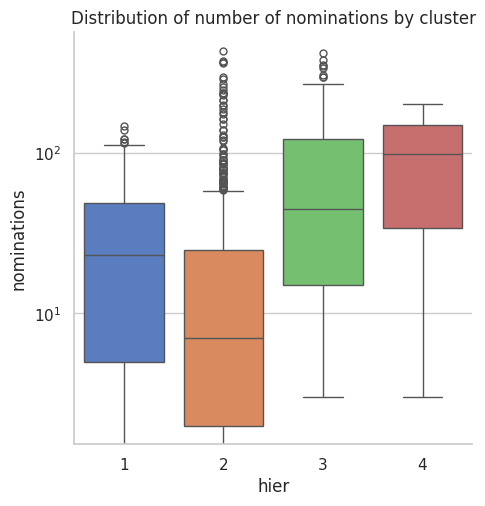

In [66]:
sns.catplot(train, x=clustering, y='nominations', kind='box', hue=clustering, legend=False)
plt.title("Distribution of number of nominations by cluster")
plt.yscale('log')
plt.show()

Records from cluster 3 are rated more favorably and receive on average more awards and nominations.

<Axes: xlabel='hier'>

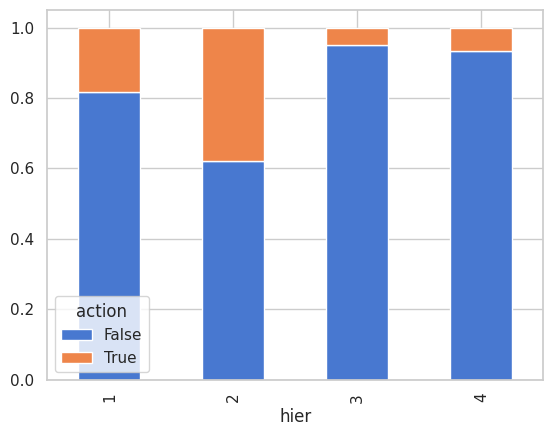

In [67]:
train['action'] = train['genre'].map(lambda x: 'Action' in x)
action_by_clust = pd.crosstab(train[clustering], train['action'], normalize='index')
action_by_clust.plot.bar(stacked='True')

In [68]:
action_by_clust

action,False,True
hier,,
1,0.815789,0.184211
2,0.620061,0.379939
3,0.950495,0.049505
4,0.933333,0.066667


<Axes: xlabel='hier'>

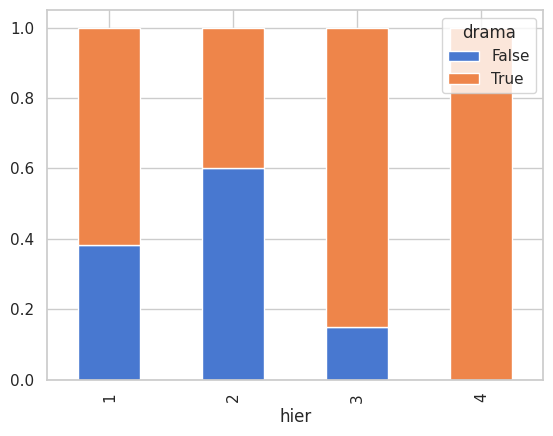

In [69]:
train['drama'] = train['genre'].map(lambda x: 'Drama' in x)
drama_by_clust = pd.crosstab(train[clustering], train['drama'], normalize='index')
drama_by_clust.plot.bar(stacked='True')

In [70]:
drama_by_clust

drama,False,True
hier,,
1,0.381579,0.618421
2,0.601824,0.398176
3,0.148515,0.851485
4,0.000000,1.000000


Action movies are underrepresented in cluster 3, while dramatic movies are overrepresented (dramatic movies make up about half of the dataset but more than 85% of cluster 3).

<Axes: xlabel='hier'>

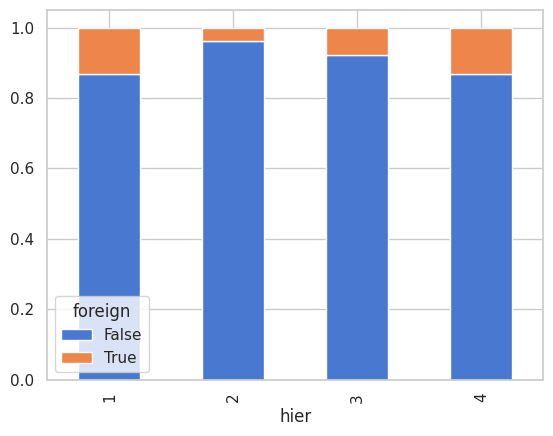

In [71]:
train['foreign'] = train['countryOfOrigin'].apply(lambda x: 'US' not in x)
pd.crosstab(train[clustering], train['foreign'], normalize='index').plot.bar(stacked=True)

<Axes: xlabel='hier'>

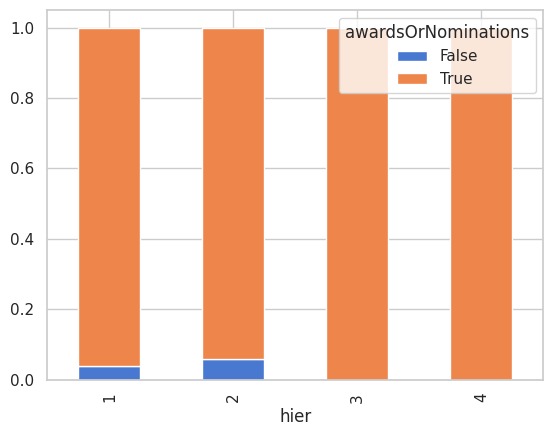

In [72]:
pd.crosstab(train[clustering], train['awardsOrNominations'], normalize='index').plot.bar(stacked='True')

## Dimensionality reduction

In [73]:
from sktime.transformations.panel.reduce import Tabularizer
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

### PCA

In [74]:
pca_compressor = Tabularizer() * StandardScaler() * PCA(random_state=42)
pca_compressor

TransformerPipeline(steps=[Tabularizer(),
                           TabularToSeriesAdaptor(transformer=StandardScaler()),
                           TabularToSeriesAdaptor(transformer=PCA(random_state=42))])

In [75]:
pca_train = pca_compressor.fit_transform(train_X)
pca_train.index = train.index
pca_train.shape

(850, 100)

In [76]:
pca = pca_compressor.steps_[-1][1].transformer_
explained_variance = pca.explained_variance_ratio_

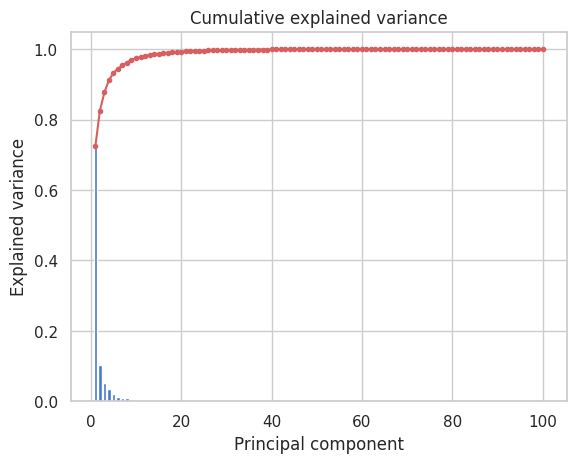

In [77]:
x = list(range(1, len(explained_variance) + 1))
plt.bar(x, height=explained_variance)
plt.plot(x, explained_variance.cumsum(), 'r.-')
plt.xlabel("Principal component")
plt.ylabel("Explained variance")
plt.title("Cumulative explained variance")
plt.show()

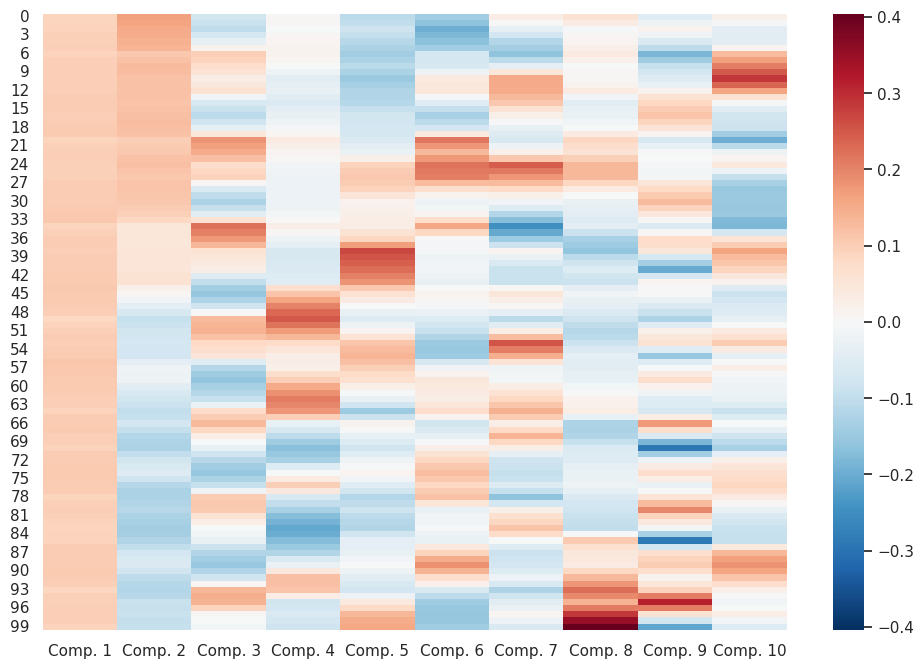

In [78]:
n_comp = 10

components = pca.components_[:n_comp].T
vmax = np.abs(components).max()

plt.figure(figsize=(2+n_comp, 8))
sns.heatmap(components, cmap='RdBu_r', vmax=vmax, vmin=-vmax)
plt.xticks(np.arange(n_comp) + .5, labels=[f'Comp. {i+1}' for i in range(n_comp)])
plt.show()

First two components explain more than 80% of the variance. Though it doesn't look like the first two components are able to capture satisfactorily our clustering.
All timestamps contribute more or less equaly to the first component, while only earlier timestamps contribute to the second component, which explains why records from cluster 3 tend to have lower values for the second component.

In [79]:
cluster_palette = [f'C{i}'
                   for i in range(1, 5)]

Text(47.25031249999999, 0.5, 'PCA 2: explains 0.1 of variance')

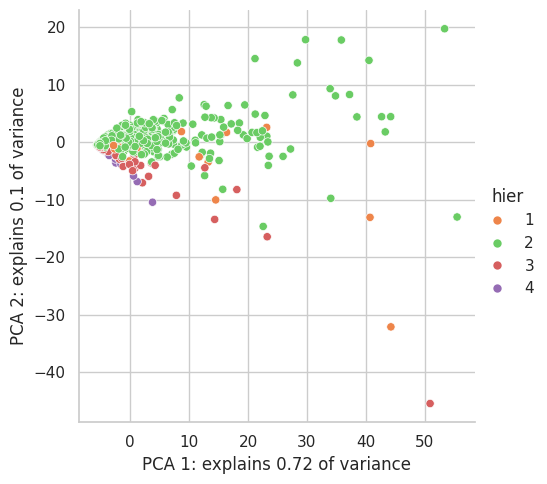

In [80]:
x, y = 0, 1
g = sns.relplot(pca_train, x=x, y=y, hue=train['hier'], palette=cluster_palette)
plt.xlabel(f"PCA {x+1}: explains {round(explained_variance[x], 2)} of variance")
plt.ylabel(f"PCA {y+1}: explains {round(explained_variance[y], 2)} of variance")


### TSNE

We compute tsne on the distance matrix. TSNE preserves the local structure of the data, so this is a better visualization of our clustering. (We tried some values of perplexity and retained the one which gave better results)

In [81]:
tsne = TSNE(n_components=2, metric='precomputed', init='random', perplexity=40, random_state=42)
tsne_train = pd.DataFrame(tsne.fit_transform(dist_matrix))
tsne_train.index = train.index

Text(47.25031249999999, 0.5, 'TSNE 2')

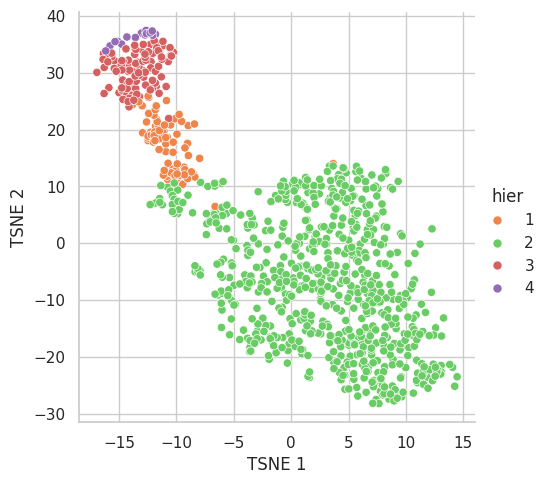

In [82]:
sns.relplot(tsne_train, x=x, y=y, hue=train['hier'], palette=cluster_palette)
plt.xlabel(f"TSNE {x+1}")
plt.ylabel(f"TSNE {y+1}")